## Objetivo da Aula:

* Apresentar conceitos básicos de visualização de dados utilizando Seaborn, aplicada a uma base de dados fictícia relacionada à saúde.

## Base de Dados Fictícia:

* Nome do Dataset: DadosSaude

### Colunas:
* ID_Paciente: Identificador único do paciente
* Idade: Idade do paciente
* Genero: Gênero do paciente (Masculino, Feminino, Outro)
* Pressao_Arterial: Pressão arterial média (mm Hg)
* Nivel_Colesterol: Nível de colesterol (mg/dL)
* IMC: Índice de Massa Corporal
* Diabetes: Diagnóstico de diabetes (Sim, Não)
* Fumante: Se o paciente é fumante (Sim, Não)
* Atividade_Fisica: Nível de atividade física semanal (em horas)
* Medicacao: Uso de medicação para pressão arterial (Sim, Não)

## Agenda:

* Introdução ao Seaborn:

    * Breve apresentação da biblioteca Seaborn.
    * Comparação com outras bibliotecas de visualização, como Matplotlib.

Importação de Bibliotecas e Carregamento dos Dados:

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(42)  # Para reprodutibilidade

num_pacientes = 100

ID_Paciente = range(1, num_pacientes + 1)

# Idade dos Pacientes (Distribuição Normal com média 50 e desvio padrão 15)
Idade = np.random.normal(50, 15, num_pacientes).astype(int)
Idade = np.clip(Idade, 18, 90)  # Limitando as idades entre 18 e 90 anos

# Gênero dos Pacientes (Distribuição Uniforme)
Genero = np.random.choice(['Masculino', 'Feminino', 'Outro'], num_pacientes, p=[0.48, 0.48, 0.04])

# Fumante (Maior probabilidade em idades menores)
Fumante = np.where(Idade < 50,
                   np.random.choice(['Sim', 'Não'], p=[0.4, 0.6], size=num_pacientes),
                   np.random.choice(['Sim', 'Não'], p=[0.2, 0.8], size=num_pacientes))

# Índice de Massa Corporal (IMC) (Maior em pacientes mais velhos)
IMC = np.where(Idade < 40,
               np.random.normal(24, 3, num_pacientes),
               np.random.normal(28, 4, num_pacientes))
IMC = np.clip(IMC, 16, 45)

# Diagnóstico de Diabetes (Mais provável em pacientes com IMC alto)
Diabetes = np.where((IMC > 30) & (Idade > 50),
                    np.random.choice(['Sim', 'Não'], p=[0.7, 0.3], size=num_pacientes),
                    np.random.choice(['Sim', 'Não'], p=[0.2, 0.8], size=num_pacientes))

# Pressão Arterial (Relacionado à Idade, Fumante e Diabetes)
# Pacientes fumantes e/ou com diabetes têm maior probabilidade de pressão alta
Pressao_Arterial = np.random.normal(120, 10, num_pacientes)
Pressao_Arterial += (Idade / 10)  # Aumento gradual com a idade
Pressao_Arterial += np.where(Fumante == 'Sim', 10, 0)  # Fumantes têm pressão mais alta
Pressao_Arterial += np.where(Diabetes == 'Sim', 10, 0)  # Diabéticos têm pressão mais alta
Pressao_Arterial = np.clip(Pressao_Arterial, 80, 200)

# Nível de Colesterol (Mais alto em idades avançadas e com variabilidade maior em fumantes e diabéticos)
Nivel_Colesterol = np.random.normal(180, 20, num_pacientes)  # Base inicial mais baixa
Nivel_Colesterol += (Idade * 0.5)  # Aumento mais significativo com a idade
Nivel_Colesterol += np.where(Fumante == 'Sim', 30, 0)  # Fumantes têm colesterol mais alto
Nivel_Colesterol += np.where(Diabetes == 'Sim', 40, 0)  # Diabéticos têm colesterol mais alto
Nivel_Colesterol -= np.where(Idade <= 35, 25, 0)  # Pessoas mais novas devem ter um nível de colesterol mais baixo
Nivel_Colesterol = np.clip(Nivel_Colesterol, 100, 350)

# Nível de Atividade Física (Em horas por semana) (Menor em pacientes mais velhos)
Atividade_Fisica = np.where(Idade < 50,
                            np.random.normal(4, 2, num_pacientes),
                            np.random.normal(2, 1.5, num_pacientes))
Atividade_Fisica -= np.where(Fumante == 'Sim', 2, 0)  # Fumantes praticam menos atividades físicas
Atividade_Fisica = np.clip(Atividade_Fisica, 0, 10)

#ajustes com base na atividade física
Pressao_Arterial += np.where(Atividade_Fisica < 2, 20, 0)  # Quem não pratica atividade física têm pressão mais alta
Pressao_Arterial = np.clip(Pressao_Arterial, 80, 200)

Nivel_Colesterol += np.where(Atividade_Fisica < 1, 30, 0)  # Quem não pratica atividade física têm Nivel_Colesterol alto
Nivel_Colesterol += np.where((Atividade_Fisica >= 1) & (Atividade_Fisica < 3), 20, 0)  # Quem pratica atividade física entre 1 e 3 horas tem aumento de 20 no Nivel_Colesterol
Nivel_Colesterol = np.clip(Pressao_Arterial, 80, 200)

# Uso de medicação para pressão arterial (Mais comum em pacientes mais velhos e com pressão alta)
Medicacao = np.where(Pressao_Arterial > 140,
                     np.random.choice(['Sim', 'Não'], p=[0.8, 0.2], size=num_pacientes),
                     np.random.choice(['Sim', 'Não'], p=[0.2, 0.8], size=num_pacientes))

# Criação do DataFrame com os dados gerados
dados = {
    'ID_Paciente': ID_Paciente,
    'Idade': Idade,
    'Genero': Genero,
    'Pressao_Arterial': Pressao_Arterial,
    'Nivel_Colesterol': Nivel_Colesterol,
    'IMC': IMC,
    'Diabetes': Diabetes,
    'Fumante': Fumante,
    'Atividade_Fisica': Atividade_Fisica,
    'Medicacao': Medicacao,
}

df = pd.DataFrame(dados)
df.head()

,ID_Paciente,Idade,Genero,Pressao_Arterial,Nivel_Colesterol,IMC,Diabetes,Fumante,Atividade_Fisica,Medicacao
0,1,57,Masculino,154.940270,154.940270,21.186470,Não,Não,1.143232,Sim
1,2,47,Masculino,122.850979,122.850979,27.777809,Não,Não,2.366129,Sim
2,3,59,Masculino,130.672770,130.672770,29.536262,Não,Sim,2.099033,Não
3,4,72,Masculino,167.690092,167.690092,27.869221,Não,Sim,1.386951,Não
4,5,46,Feminino,127.556563,127.556563,19.730232,Não,Sim,2.057490,Não


In [2]:
df.tail()

,ID_Paciente,Idade,Genero,Pressao_Arterial,Nivel_Colesterol,IMC,Diabetes,Fumante,Atividade_Fisica,Medicacao
95,96,28,Masculino,120.032514,120.032514,26.152627,Sim,Não,2.636032,Não
96,97,54,Outro,114.589435,114.589435,25.392656,Não,Não,3.098960,Não
97,98,53,Masculino,165.831529,165.831529,28.189595,Sim,Não,1.878925,Não
98,99,50,Feminino,134.604448,134.604448,24.558347,Sim,Não,2.117953,Não
99,100,46,Feminino,141.415007,141.415007,26.461778,Não,Sim,3.281686,Não


## Distribuição das Varariáveis com um histograma

Histogramas são gráficos utilizados para avaliar a distribuição/frequência de dados contínuos.

É útil construir um histograma quando você deseja:

* Resumir grandes conjuntos de dados de forma visual
* Comparar os resultados
* Comunicar as informações graficamente

Observe que a idade dos pacientes segue uma **distribuição normal**, concentrada em torno de 50 anos.

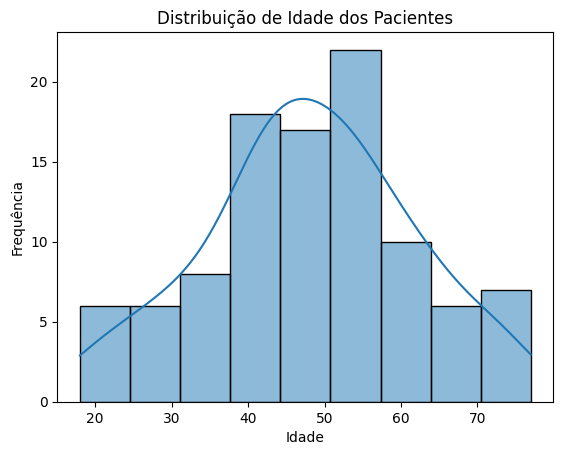

In [3]:
sns.histplot(df['Idade'], kde=True)
plt.title('Distribuição de Idade dos Pacientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

* Comparando distribuições

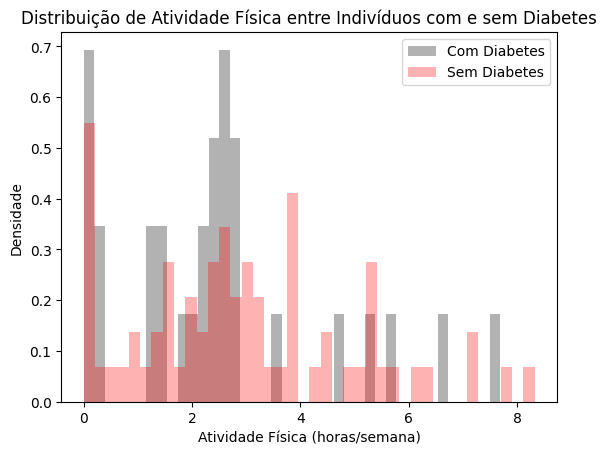

In [13]:
a = df.loc[df.Diabetes == 'Sim', 'Atividade_Fisica'].values
b = df.loc[df.Diabetes == 'Não', 'Atividade_Fisica'].values

kwargs = dict(histtype='stepfilled', alpha=0.3, density=True, bins=40)
plt.hist(a, **kwargs, label='Com Diabetes', color='black')
plt.hist(b, **kwargs, label='Sem Diabetes', color='red')

# Adicionar título, legenda e rótulos
plt.title('Distribuição de Atividade Física entre Indivíduos com e sem Diabetes')
plt.xlabel('Atividade Física (horas/semana)')
plt.ylabel('Densidade')
plt.legend(loc='upper right')

plt.show()

## Exercício Prática 01 (não avaliativo)

Na célula abaixo, crie um histograma comparando as distribuições de atividade física entre Fumantes e Não Fumantes

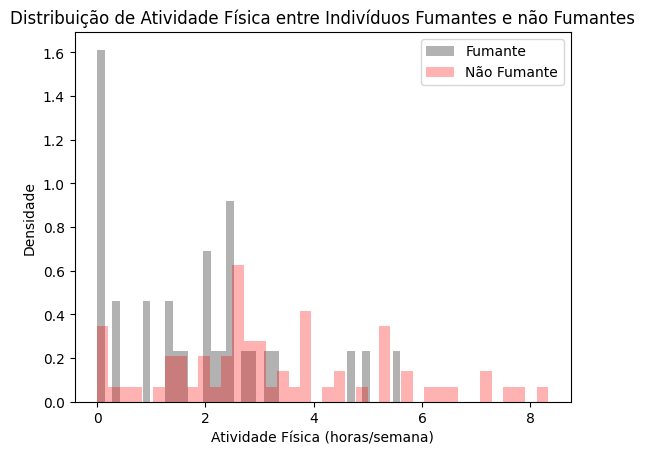

In [14]:
a = df.loc[df.Fumante == 'Sim', 'Atividade_Fisica'].values
b = df.loc[df.Fumante == 'Não', 'Atividade_Fisica'].values

kwargs = dict(histtype='stepfilled', alpha=0.3, density=True, bins=40)
plt.hist(a, **kwargs, label='Fumante', color='black')
plt.hist(b, **kwargs, label='Não Fumante', color='red')

# Adicionar título, legenda e rótulos
plt.title('Distribuição de Atividade Física entre Indivíduos Fumantes e não Fumantes')
plt.xlabel('Atividade Física (horas/semana)')
plt.ylabel('Densidade')
plt.legend(loc='upper right')

plt.show()

## Gráfico de dispersão (scatter plot)

Um gráfico de dispersão, também conhecido como scatter plot, é uma ferramenta visual utilizada para representar a relação entre duas variáveis numéricas. Cada ponto no gráfico representa uma observação do conjunto de dados, com a posição horizontal (eixo X) indicando o valor de uma variável e a posição vertical (eixo Y) indicando o valor da outra variável.

Esse tipo de gráfico é especialmente útil para identificar padrões, tendências e possíveis correlações entre as variáveis. Além disso, ele pode revelar a presença de outliers (valores atípicos) e a direção e intensidade de uma possível relação linear ou não linear entre as variáveis.

A seguir temos um gráfico de que mostra a relação entre o Índice de Massa Corporal (IMC) e a Pressão Arterial dos indivíduos na base de dados. A variável 'IMC' está no eixo X, enquanto a 'Pressão Arterial' está no eixo Y. Além disso, a variável 'Fumante' é utilizada para colorir os pontos, permitindo visualizar como o hábito de fumar pode influenciar essa relação. Isso pode ajudar a identificar se existe uma correlação entre o IMC e a Pressão Arterial e se essa relação é diferente entre fumantes e não fumantes.

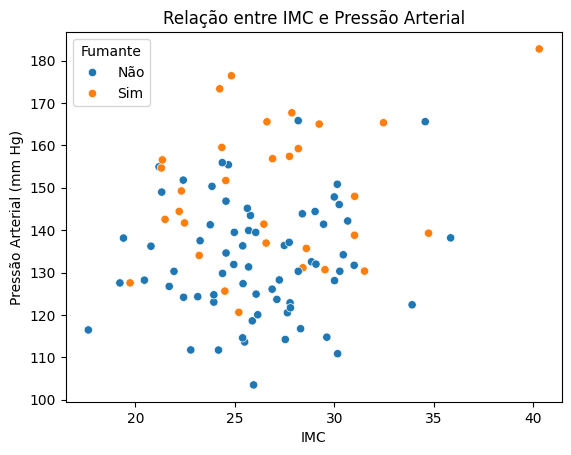

In [5]:
sns.scatterplot(x='IMC', y='Pressao_Arterial', data=df, hue='Fumante')
plt.title('Relação entre IMC e Pressão Arterial')
plt.xlabel('IMC')
plt.ylabel('Pressão Arterial (mm Hg)')
plt.show()

## Exercício Prática 02 (não avaliativo)

Crie um gráfico de dispersão da relação entre Atividade Física e Pressão Arterial. As cores dos pontos devem ser discriminados de acordo com o conteúdo da coluna "Diabetes".

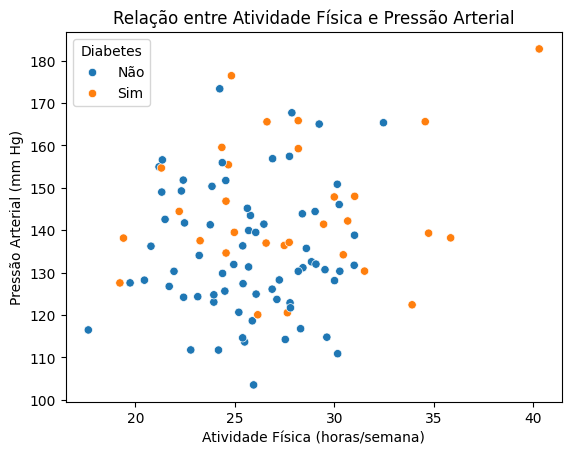

In [18]:
import matplotlib.pyplot as plt
sns.scatterplot(x='IMC', y='Pressao_Arterial', data=df, hue='Diabetes')
plt.title('Relação entre Atividade Física e Pressão Arterial')
plt.xlabel('Atividade Física (horas/semana)')
plt.ylabel('Pressão Arterial (mm Hg)')
plt.show()

### Gráfico de Linhas

Um gráfico de linhas (line plot) é uma ferramenta de visualização que exibe dados ao longo de um eixo contínuo, como o tempo ou a idade, conectando pontos de dados consecutivos com linhas. Esse tipo de gráfico é ideal para mostrar tendências, variações e padrões em séries temporais ou qualquer outro conjunto de dados em que a ordem das observações é significativa.

Ex.: cotação de ações -> bitcoin.

A seguir temos um gráfico de linhas que mostra como o Nível de Colesterol varia com base na Idade dos indivíduos da base de dados. A variável 'Idade' está no eixo X, enquanto o 'Nível de Colesterol' está no eixo Y. A variável 'Fumante' é usada para diferenciar as linhas, permitindo visualizar se a presença da condição Fumante influencia o nível de colesterol ao longo das diferentes faixas etárias.

Este gráfico ajuda a identificar tendências gerais, como o aumento ou diminuição do colesterol com a idade, e também a comparar essas tendências entre indivíduos com e sem a condição de Fumante. É uma ferramenta útil para analisar como o colesterol se comporta ao longo da vida e se o fumo exerce um impacto significativo nesse comportamento.

Observe ainda que as **áreas mais transparentes** em um gráfico de linhas geralmente indicam a presença de múltiplos **dados sobrepostos**. Isso ocorre quando **várias observações têm valores muito próximos ou idênticos** para as mesmas variáveis (no caso, 'Idade' e 'Nível de Colesterol'). O seaborn.lineplot automaticamente ajusta a transparência das linhas para refletir a densidade dos dados em determinadas áreas.

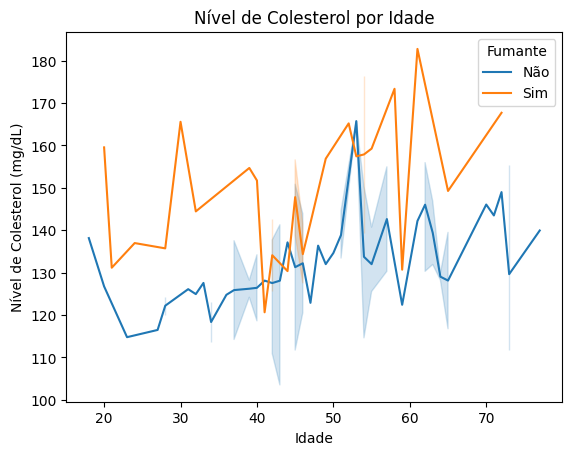

In [6]:
sns.lineplot(x='Idade', y='Nivel_Colesterol', data=df, hue='Fumante')
plt.title('Nível de Colesterol por Idade')
plt.xlabel('Idade')
plt.ylabel('Nível de Colesterol (mg/dL)')
plt.show()

## Exercício Prática 03 (não avaliativo)

Crie um gráfico de linhas da Pressão Arterial em relação à idade dos pacientes. As linhas devem ser discriminados de acordo com o conteúdo da coluna "Diabetes".

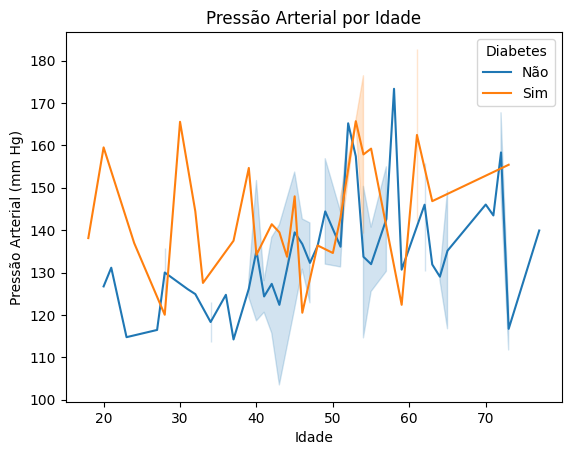

In [22]:
import matplotlib.pyplot as plt
sns.lineplot(x='Idade', y='Nivel_Colesterol', data=df, hue='Diabetes')
plt.title('Pressão Arterial por Idade')
plt.xlabel('Idade')
plt.ylabel('Pressão Arterial (mm Hg)')
plt.show()

### Gráfico de caixa (boxsplot)

Um gráfico de caixa, ou boxplot, é uma ferramenta de visualização que resume a distribuição de um conjunto de dados numéricos através de cinco principais estatísticas: o mínimo (Q1 - 1.5xIQR), o primeiro quartil (Q1), a mediana (Q2), o terceiro quartil (Q3) e o máximo (Q3 + 1.5xIQR). Ele também pode destacar valores atípicos (outliers), que são pontos de dados que se encontram fora do intervalo interquartil (a distância de 1.5*IQR para menos que Q1 e para mais que Q3).

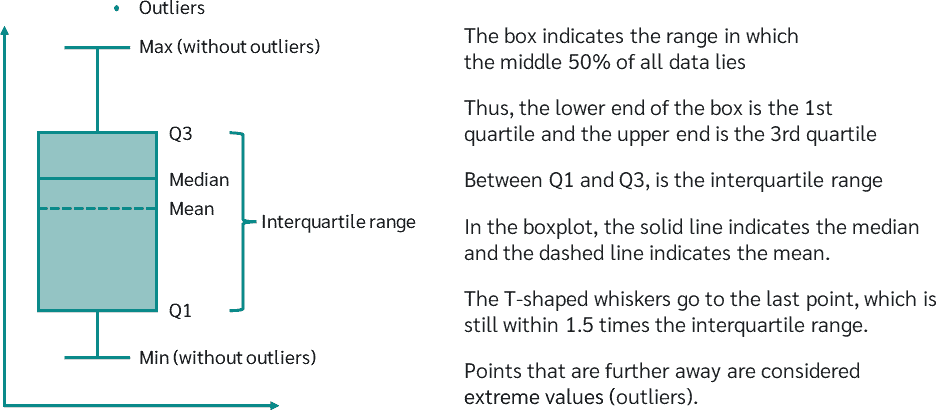

O boxplot é útil para visualizar a dispersão dos dados, identificar a simetria ou assimetria da distribuição, e comparar a distribuição de uma variável entre diferentes grupos. Ele é particularmente valioso em análises exploratórias de dados para detectar variações e possíveis anomalias.

Para saber mais sobre boxplot, acesse:

* [Vídeo explicativo](https://pt.khanacademy.org/math/ap-statistics/summarizing-quantitative-data-ap/stats-box-whisker-plots/v/reading-box-and-whisker-plots)
* [Link explicativo (português)](https://doc.arcgis.com/pt-br/insights/latest/create/box-plot.htm)
* [Link explicativo (inglês)](https://datatab.net/tutorial/box-plot)

Neste contexto, o gráfico seguinte de caixa mostra a distribuição do Índice de Massa Corporal (IMC) em função do gênero dos indivíduos na base de dados. A variável 'Gênero' é representada no eixo X, enquanto o 'IMC' é mostrado no eixo Y.

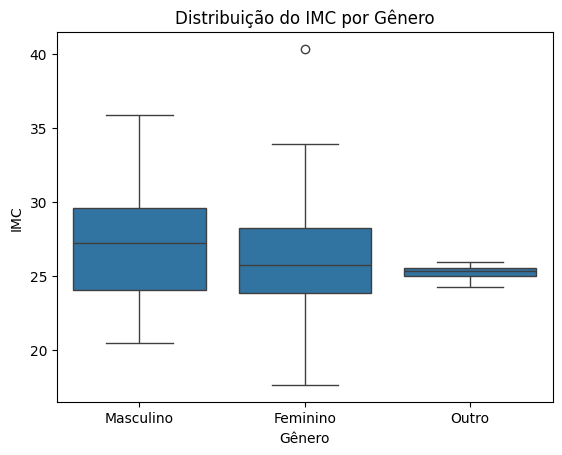

In [7]:
sns.boxplot(x='Genero', y='IMC', data=df)
plt.title('Distribuição do IMC por Gênero')
plt.xlabel('Gênero')
plt.ylabel('IMC')
plt.show()

## Exercício Prática 04 (não avaliativo)

Crie um gráfico de caixa para comparar as distribuições da pressão arterial de indíviduos com e sem diabetes.

In [30]:
print(df.columns)

Index(['ID_Paciente', 'Idade', 'Genero', 'Pressao_Arterial',
       'Nivel_Colesterol', 'IMC', 'Diabetes', 'Fumante', 'Atividade_Fisica',
       'Medicacao'],
      dtype='object')


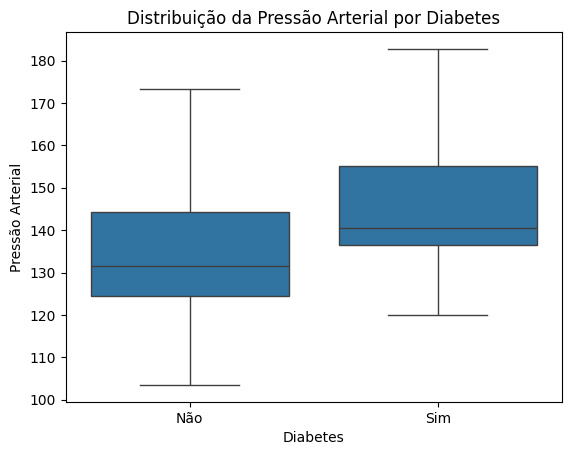

In [31]:
sns.boxplot(x='Diabetes', y='Pressao_Arterial', data=df)
plt.title('Distribuição da Pressão Arterial por Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Pressão Arterial')
plt.show()

### Gráfico de Barras

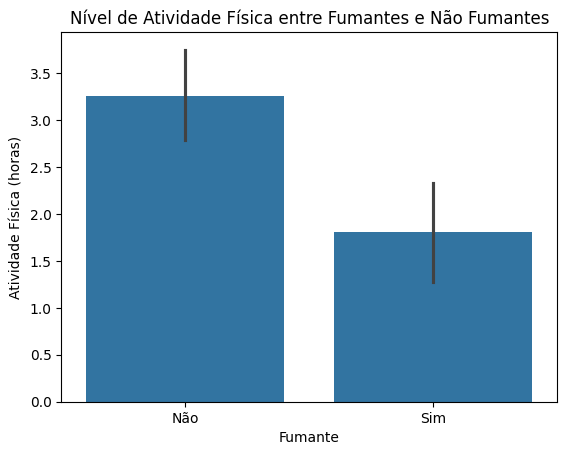

In [32]:
sns.barplot(x='Fumante', y='Atividade_Fisica', data=df)
plt.title('Nível de Atividade Física entre Fumantes e Não Fumantes')
plt.xlabel('Fumante')
plt.ylabel('Atividade Física (horas)')
plt.show()

## Exercício Prática 05 (não avaliativo)

Crie um gráfico de barras para comparar a tempo de atividade física de um paciente com e sem diabetes.

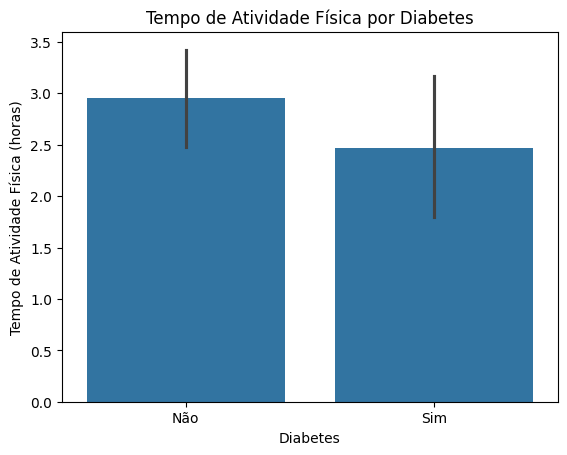

In [33]:
sns.barplot(x='Diabetes', y='Atividade_Fisica', data=df)
plt.title('Tempo de Atividade Física por Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Tempo de Atividade Física (horas)')
plt.show()


## Gráfico: Impacto do Diabetes e Tabagismo no Nível de Colesterol

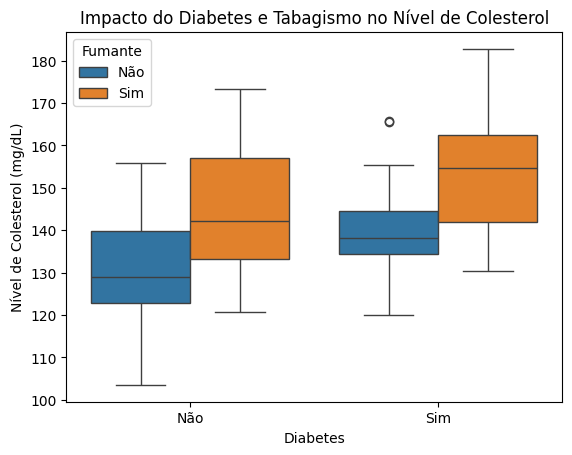

In [34]:
# Gráfico de Impacto do Diabetes e Tabagismo no Nível de Colesterol
sns.boxplot(x='Diabetes', y='Nivel_Colesterol', hue='Fumante', data=df)
plt.title('Impacto do Diabetes e Tabagismo no Nível de Colesterol')
plt.xlabel('Diabetes')
plt.ylabel('Nível de Colesterol (mg/dL)')
plt.legend(title='Fumante')
plt.show()

## Gráfico: Correlação entre Nível de Colesterol e Idade

In [35]:
df.columns

Index(['ID_Paciente', 'Idade', 'Genero', 'Pressao_Arterial',
       'Nivel_Colesterol', 'IMC', 'Diabetes', 'Fumante', 'Atividade_Fisica',
       'Medicacao'],
      dtype='object')

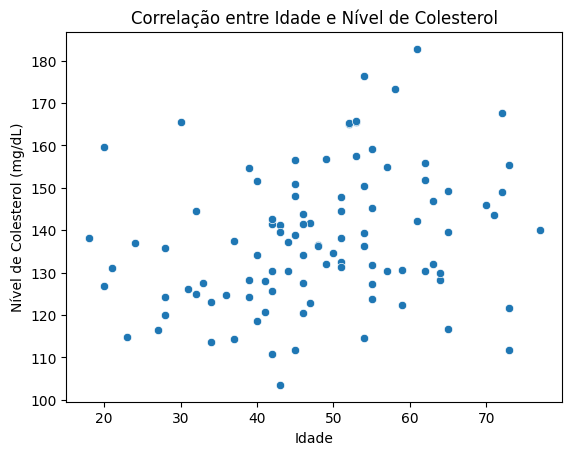

In [36]:
# Gráfico de Correlação entre Idade e Nível de Colesterol
sns.scatterplot(x='Idade', y='Nivel_Colesterol', data=df)
plt.title('Correlação entre Idade e Nível de Colesterol')
plt.xlabel('Idade')
plt.ylabel('Nível de Colesterol (mg/dL)')
plt.show()

## Gráfico: Correlação entre Nível de Colesterol e Idade, considerando Atividade Física

* O parâmetro `size='Atividade_Fisica'` ajusta o tamanho dos pontos no gráfico com base na quantidade de atividade física realizada pelos indivíduos.
* O intervalo de tamanhos é definido por `sizes=(20, 200)`, onde 20 é o tamanho mínimo e 200 o máximo.
* O parâmetro `hue='Atividade_Fisica'` adiciona uma camada de cor, representando visualmente diferentes níveis de atividade física. A paleta `coolwarm` ajuda a distinguir entre níveis baixos e altos de atividade.
* `alpha=0.6` ajuda a reduzir a sobreposição e melhora a legibilidade do gráfico, especialmente em áreas densamente povoadas.
* `edgecolor='w'` adiciona bordas brancas aos pontos para melhorar a separação visual entre eles.
* A legenda foi ajustada para mostrar claramente o que as diferentes cores e tamanhos representam, facilitando a interpretação do gráfico.

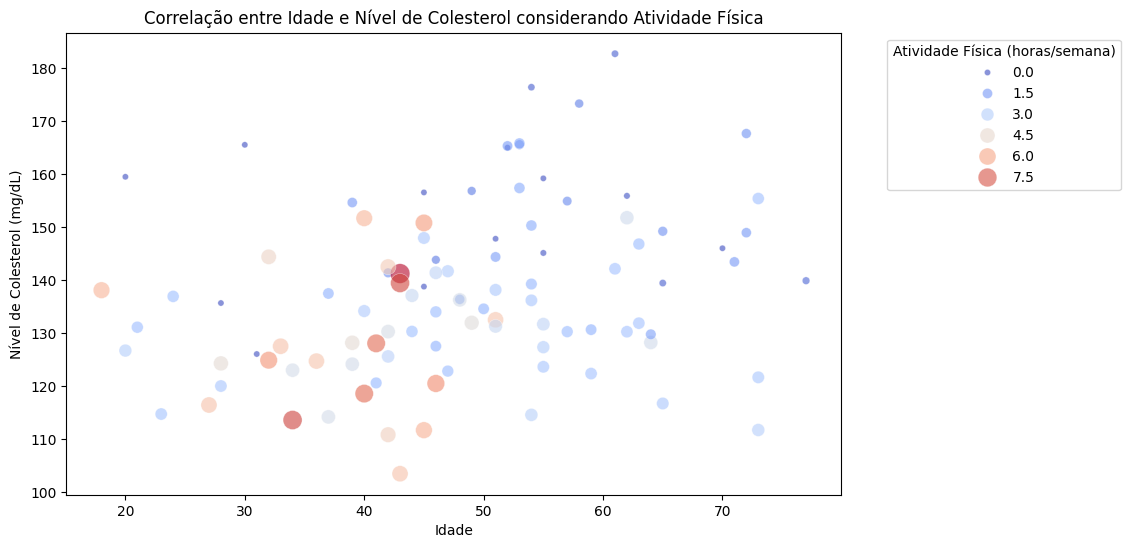

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='Idade', y='Nivel_Colesterol', data=df,
                size='Atividade_Fisica', sizes=(20, 200),
                hue='Atividade_Fisica', palette='coolwarm', alpha=0.6, edgecolor='w')

# Título e rótulos
plt.title('Correlação entre Idade e Nível de Colesterol considerando Atividade Física')
plt.xlabel('Idade')
plt.ylabel('Nível de Colesterol (mg/dL)')

# Legenda e ajustes
plt.legend(title='Atividade Física (horas/semana)', bbox_to_anchor=(1.05, 1))
plt.show()

## Gráfico: Correlação entre Nível de Colesterol e Idade, considerando Atividade Física e Pressão Arterial

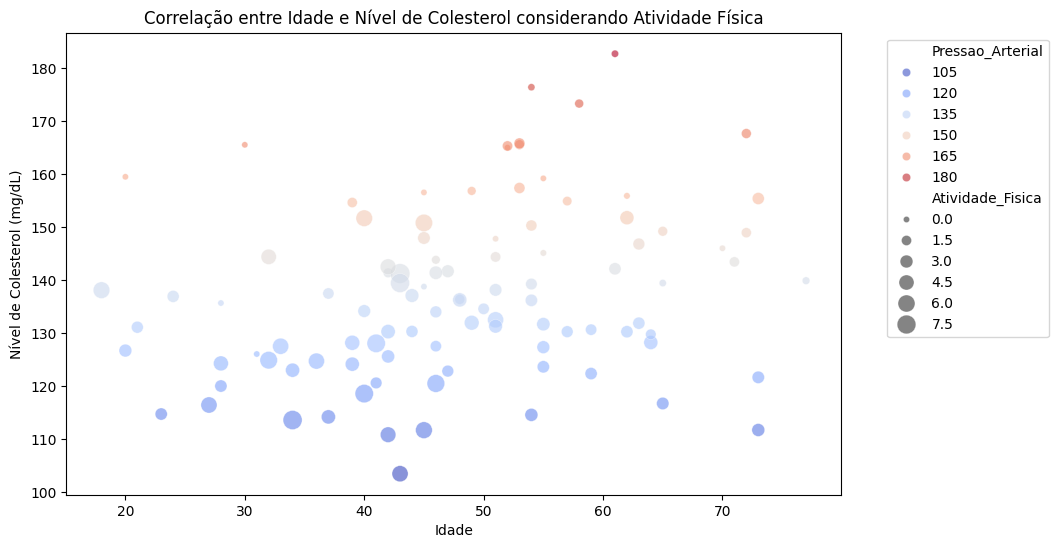

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='Idade', y='Nivel_Colesterol', data=df,
                size='Atividade_Fisica', sizes=(20, 200),
                hue='Pressao_Arterial', palette='coolwarm', alpha=0.6, edgecolor='w')

plt.title('Correlação entre Idade e Nível de Colesterol considerando Atividade Física')
plt.xlabel('Idade')
plt.ylabel('Nível de Colesterol (mg/dL)')

plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

## Atividade em sala 01

### Desafio de Identificação de Padrões:

Faça uma cópia deste arquivo de código no seu drive. Após isso, faça ajustes nos valores da base de dados fornecida para que seja possível observar novos padrões e tendências nos gráficos subsequentes. Considere como diferentes variáveis podem interagir entre si e como essas interações podem ser refletidas visualmente. Seu objetivo é manipular os dados de forma que os gráficos revelem insights significativos e padrões claros, facilitando a interpretação e análise dos resultados.

Envie um relatório simples (com gráficos e texto), feito em um editor de texto ou no Collab, apontando as mudanças realizadas e os novos padrões encontrados.

Observe que ao rodar o comando `df.describe()` na célula seguinte, os valores impressos devem ser diferentes após a modificação da base de dados.

In [ ]:
df.describe()

,ID_Paciente,Idade,Pressao_Arterial,Nivel_Colesterol,IMC,Atividade_Fisica
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,48.030000,137.709499,137.709499,26.371363,2.808626
std,29.011492,13.400177,16.050674,16.050674,3.874272,2.001231
min,1.000000,18.000000,103.480706,103.480706,17.628313,0.000000
25%,25.750000,40.000000,126.563022,126.563022,23.944083,1.467614
50%,50.500000,47.500000,136.341995,136.341995,25.998015,2.591967
75%,75.250000,55.500000,147.865425,147.865425,28.662642,3.812189
max,100.000000,77.000000,182.754744,182.754744,40.315523,8.326509


## Estatísticas descritivas dos dados

In [ ]:
df.groupby('Diabetes').describe().transpose()

Diabetes                       Não         Sim
ID_Paciente      count   70.000000   30.000000
                 mean    49.457143   52.933333
                 std     29.465620   28.262237
                 min      1.000000    6.000000
                 25%     24.250000   31.750000
                 50%     48.500000   52.500000
                 75%     75.500000   74.250000
                 max    100.000000   99.000000
Idade            count   70.000000   30.000000
                 mean    49.314286   45.033333
                 std     13.360707   13.228713
                 min     20.000000   18.000000
                 25%     41.250000   37.500000
                 50%     48.500000   45.500000
                 75%     57.750000   53.750000
                 max     77.000000   73.000000
Pressao_Arterial count   70.000000   30.000000
                 mean   134.609922  144.941847
                 std     15.236423   15.805735
                 min    103.480706  120.032514
                 25%    124.412832  136.531146
                 50%    131.512410  140.436148
                 75%    144.262674  155.235281
                 max    173.347942  182.754744
Nivel_Colesterol count   70.000000   30.000000
                 mean   134.609922  144.941847
                 std     15.236423   15.805735
                 min    103.480706  120.032514
                 25%    124.412832  136.531146
                 50%    131.512410  140.436148
                 75%    144.262674  155.235281
                 max    173.347942  182.754744
IMC              count   70.000000   30.000000
                 mean    25.752061   27.816403
                 std      3.166544    4.929271
                 min     17.628313   19.216717
                 25%     23.785113   24.587810
                 50%     25.694821   27.565925
                 75%     28.280190   30.623184
                 max     32.478300   40.315523
Atividade_Fisica count   70.000000   30.000000
                 mean     2.956015    2.464719
                 std      2.027801    1.927054
                 min      0.000000    0.000000
                 25%      1.532271    1.320064
                 50%      2.685023    2.438845
                 75%      3.887357    2.776796
                 max      8.326509    7.693274

In [ ]:
df.groupby('Fumante').describe().transpose()

Fumante                        Não         Sim
ID_Paciente      count   69.000000   31.000000
                 mean    53.608696   43.580645
                 std     29.075570   28.099554
                 min      1.000000    3.000000
                 25%     29.000000   20.000000
                 50%     56.000000   41.000000
                 75%     79.000000   63.000000
                 max     99.000000  100.000000
Idade            count   69.000000   31.000000
                 mean    49.217391   45.387097
                 std     13.746518   12.400746
                 min     18.000000   20.000000
                 25%     40.000000   40.500000
                 50%     50.000000   46.000000
                 75%     59.000000   53.500000
                 max     77.000000   72.000000
Pressao_Arterial count   69.000000   31.000000
                 mean   132.765633  148.713588
                 std     13.424614   16.134371
                 min    103.480706  120.618146
                 25%    123.660167  136.324563
                 50%    131.706721  147.975817
                 75%    141.395706  159.377572
                 max    165.831529  182.754744
Nivel_Colesterol count   69.000000   31.000000
                 mean   132.765633  148.713588
                 std     13.424614   16.134371
                 min    103.480706  120.618146
                 25%    123.660167  136.324563
                 50%    131.706721  147.975817
                 75%    141.395706  159.377572
                 max    165.831529  182.754744
IMC              count   69.000000   31.000000
                 mean    26.204617   26.742508
                 std      3.597023    4.472048
                 min     17.628313   19.730232
                 25%     23.944461   23.724485
                 50%     25.877995   26.572979
                 75%     28.397329   28.921609
                 max     35.858901   40.315523
Atividade_Fisica count   69.000000   31.000000
                 mean     3.258301    1.807737
                 std      2.032924    1.532439
                 min      0.000000    0.000000
                 25%      1.961669    0.316772
                 50%      2.784253    1.976091
                 75%      4.373218    2.492723
                 max      8.326509    5.601881

In [ ]:
df.groupby(['Fumante', 'Diabetes']).describe()[['Atividade_Fisica', 'Pressao_Arterial', 'Nivel_Colesterol']].transpose()

Fumante                        Não                     Sim            
Diabetes                       Não         Sim         Não         Sim
Atividade_Fisica count   50.000000   19.000000   20.000000   11.000000
                 mean     3.352905    3.009343    1.963790    1.524005
                 std      2.073432    1.954300    1.547548    1.535425
                 min      0.000000    0.000000    0.000000    0.000000
                 25%      2.060798    1.972486    0.936969    0.148433
                 50%      3.073148    2.590228    2.016790    1.517528
                 75%      4.405879    3.193901    2.552580    2.492723
                 max      8.326509    7.693274    5.601881    4.658305
Pressao_Arterial count   50.000000   19.000000   20.000000   11.000000
                 mean   130.194182  139.532610  145.649271  154.285073
                 std     12.811204   12.935935   15.498299   16.481908
                 min    103.480706  120.032514  120.618146  130.333389
                 25%    122.894147  134.394394  133.306125  141.852460
                 50%    129.019376  138.124077  142.121160  154.667668
                 75%    139.804773  144.498259  156.996383  162.542555
                 max    155.925544  165.831529  173.347942  182.754744
Nivel_Colesterol count   50.000000   19.000000   20.000000   11.000000
                 mean   130.194182  139.532610  145.649271  154.285073
                 std     12.811204   12.935935   15.498299   16.481908
                 min    103.480706  120.032514  120.618146  130.333389
                 25%    122.894147  134.394394  133.306125  141.852460
                 50%    129.019376  138.124077  142.121160  154.667668
                 75%    139.804773  144.498259  156.996383  162.542555
                 max    155.925544  165.831529  173.347942  182.754744

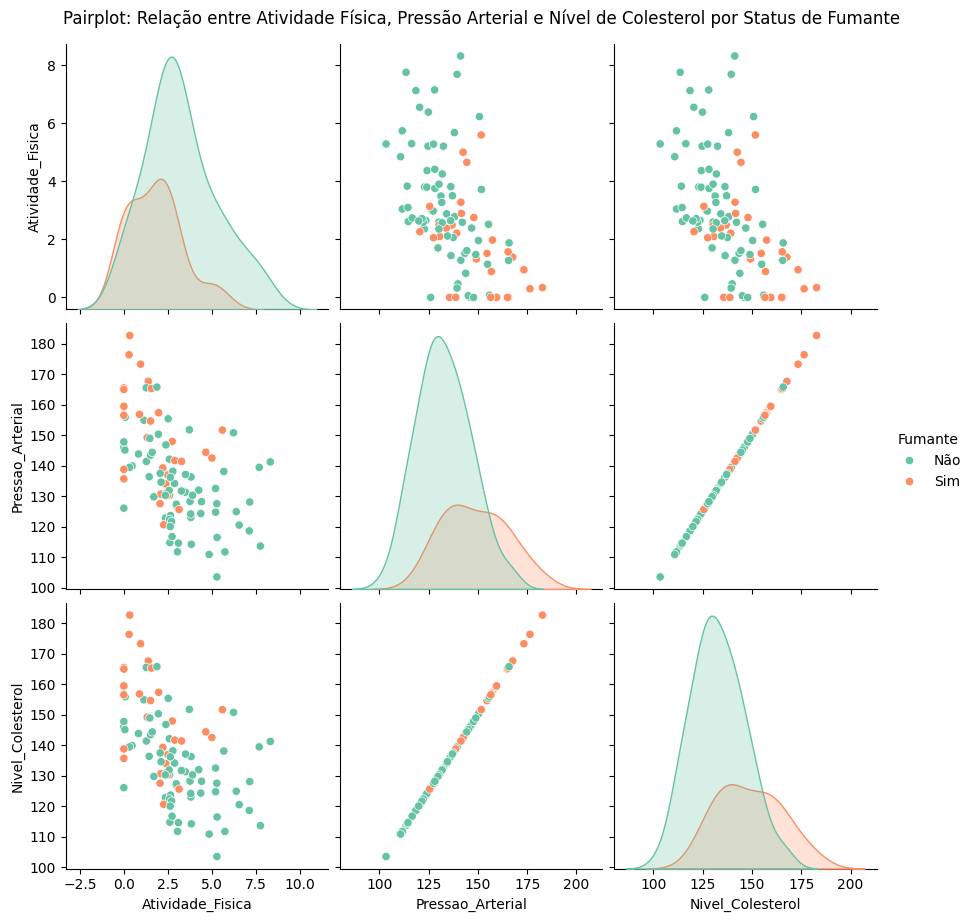

In [ ]:
# Criando um parplot diferenciado por status de Fumante e Diabetes
sns.pairplot(df, hue='Fumante', palette='Set2', vars=['Atividade_Fisica', 'Pressao_Arterial', 'Nivel_Colesterol'], kind='scatter', diag_kind='kde', height=3)
plt.suptitle('Pairplot: Relação entre Atividade Física, Pressão Arterial e Nível de Colesterol por Status de Fumante', y=1.02)
plt.show()


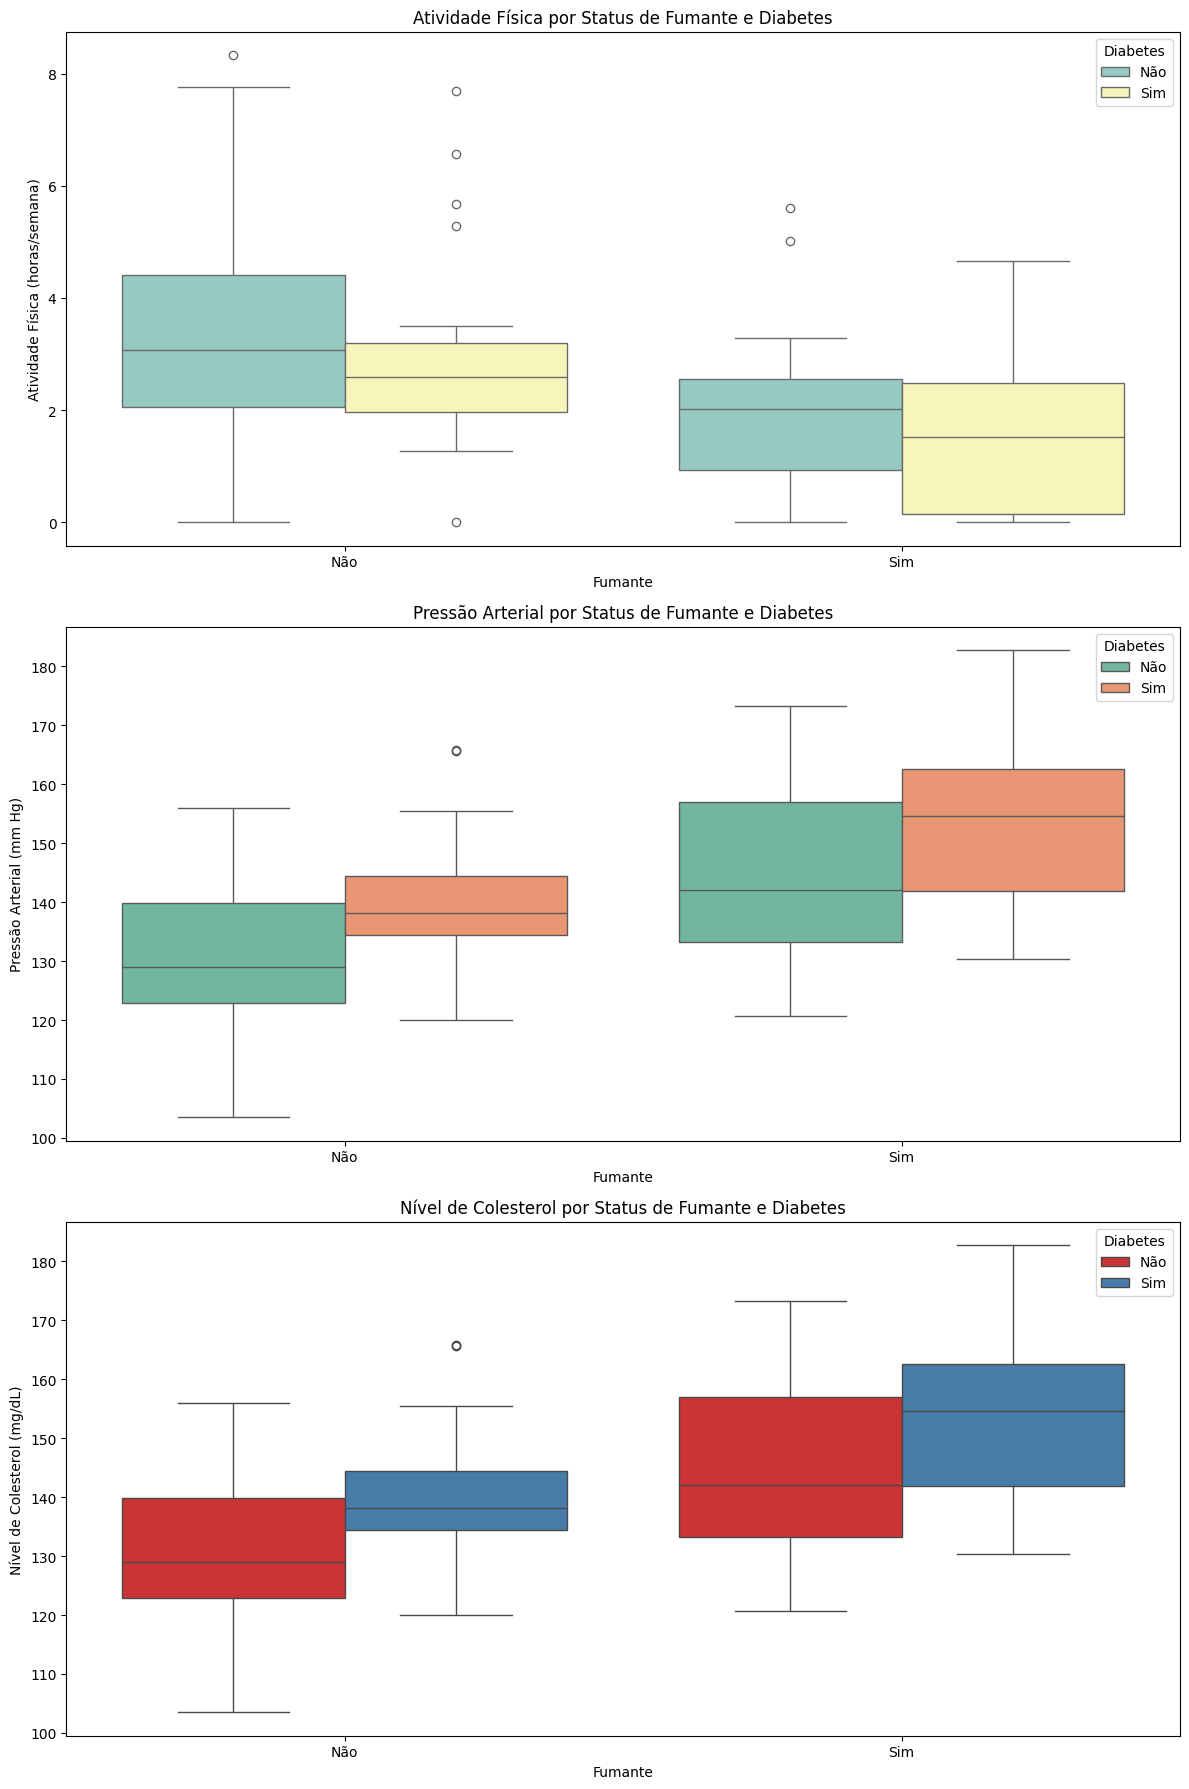

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Atividade Física
sns.boxplot(x='Fumante', y='Atividade_Fisica', hue='Diabetes', data=df, ax=axes[0], palette='Set3')
axes[0].set_title('Atividade Física por Status de Fumante e Diabetes')
axes[0].set_ylabel('Atividade Física (horas/semana)')

# Pressão Arterial
sns.boxplot(x='Fumante', y='Pressao_Arterial', hue='Diabetes', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Pressão Arterial por Status de Fumante e Diabetes')
axes[1].set_ylabel('Pressão Arterial (mm Hg)')

# Nível de Colesterol
sns.boxplot(x='Fumante', y='Nivel_Colesterol', hue='Diabetes', data=df, ax=axes[2], palette='Set1')
axes[2].set_title('Nível de Colesterol por Status de Fumante e Diabetes')
axes[2].set_ylabel('Nível de Colesterol (mg/dL)')

plt.tight_layout()
plt.show()


## Gráfico de Regressão: Pressão Arterial vs. IMC, Colorido por Status de Diabetes

Este gráfico utiliza regressão linear para explorar a relação entre IMC e pressão arterial, com uma diferenciação por status de diabetes. A intenção é ver como a pressão arterial responde ao IMC em pacientes diabéticos e não diabéticos.

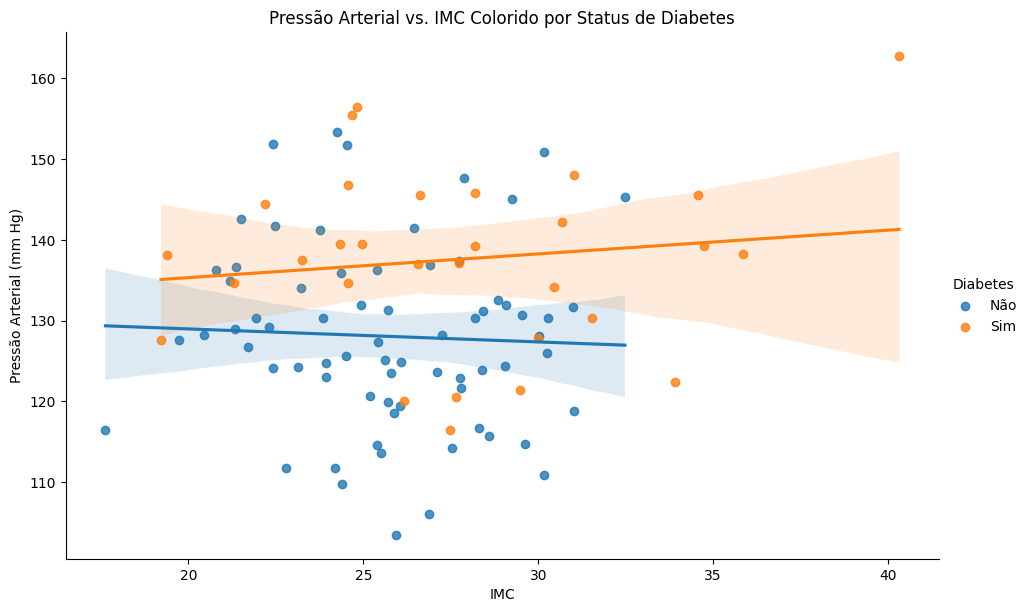

In [ ]:
sns.lmplot(x='IMC', y='Pressao_Arterial', hue='Diabetes', data=df, aspect=1.6, height=6)
plt.title('Pressão Arterial vs. IMC Colorido por Status de Diabetes')
plt.xlabel('IMC')
plt.ylabel('Pressão Arterial (mm Hg)')
plt.show()

## Gráfico de Distribuição Conjunta (Jointplot): Idade vs. Nível de Colesterol, Diferenciado por Status de Fumante

Este gráfico utiliza um jointplot para mostrar tanto a dispersão quanto as distribuições marginais da idade e do nível de colesterol, diferenciados por status de fumante.

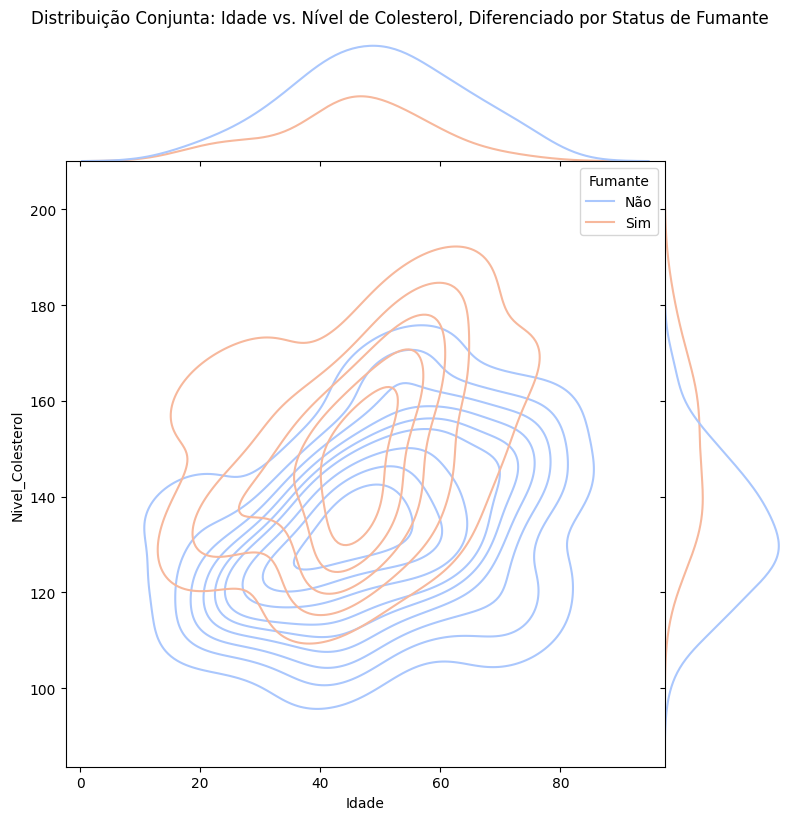

In [ ]:
sns.jointplot(x='Idade', y='Nivel_Colesterol', hue='Fumante', data=df, kind='kde', height=8, space=0, palette='coolwarm')
plt.suptitle('Distribuição Conjunta: Idade vs. Nível de Colesterol, Diferenciado por Status de Fumante', y=1.02)
plt.show()

## Exercícios resolvidos

### Questão: Pacientes diabéticos apresentam maior nível de colesterol?

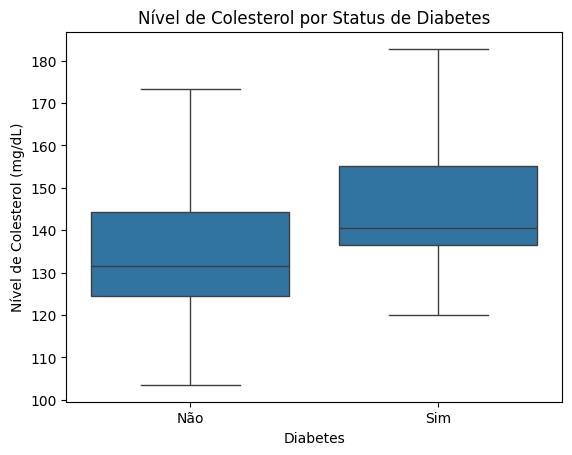

In [ ]:
sns.boxplot(x='Diabetes', y='Nivel_Colesterol', data=df)
plt.title('Nível de Colesterol por Status de Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Nível de Colesterol (mg/dL)')
plt.show()

### Questão: O colesterol aumenta com a idade?

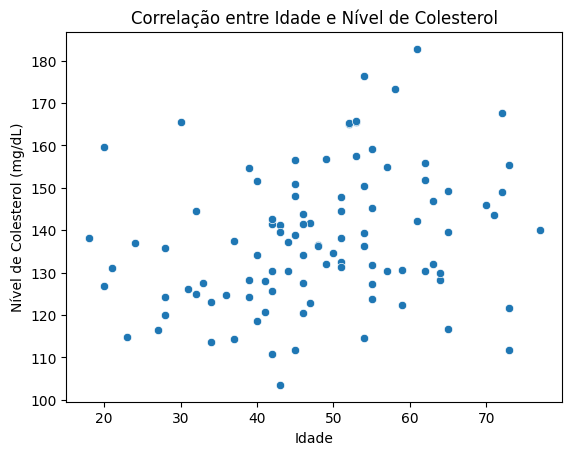

In [ ]:
sns.scatterplot(x='Idade', y='Nivel_Colesterol', data=df)
plt.title('Correlação entre Idade e Nível de Colesterol')
plt.xlabel('Idade')
plt.ylabel('Nível de Colesterol (mg/dL)')
plt.show()

### Questão: Existe uma relação entre IMC e pressão arterial?

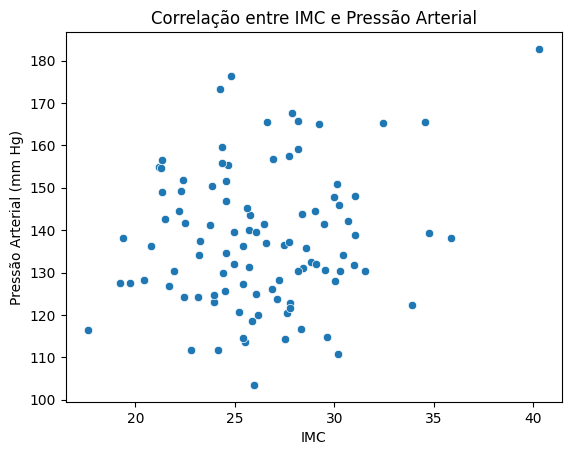

In [ ]:
sns.scatterplot(x='IMC', y='Pressao_Arterial', data=df)
plt.title('Correlação entre IMC e Pressão Arterial')
plt.xlabel('IMC')
plt.ylabel('Pressão Arterial (mm Hg)')
plt.show()

### Questão: O nível de atividade física é menor em pacientes mais velhos?

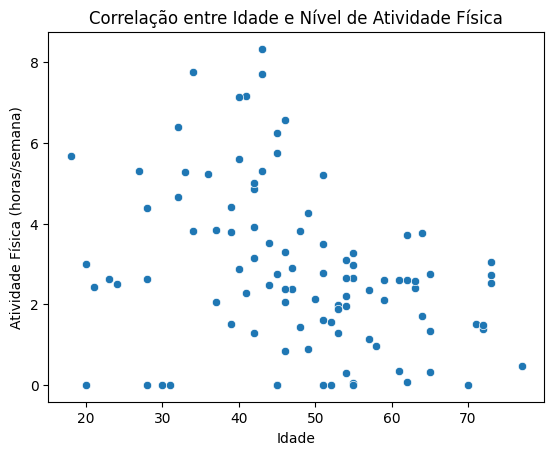

In [ ]:
sns.scatterplot(x='Idade', y='Atividade_Fisica', data=df)
plt.title('Correlação entre Idade e Nível de Atividade Física')
plt.xlabel('Idade')
plt.ylabel('Atividade Física (horas/semana)')
plt.show()

## Atividade em sala 02

Gere gráficos para visualizar tentar resposder às seguintes questões de pesquisa para esta base de dados:

1. Fumantes possuem maior Pressão Arterial?
2. Qual a relação da Diabetes e Pressão Arterial?
3. Qual a relação entre Idade e Pressão Arterial?
4. Quais são os fatores de risco para o colesterol?
5. Qual a relação entre IMC e Diabetes?
6. Existe alguma tendência visual entre atividade Física e Idade?
7. Pacientes com pressão arterial elevada (acima de 140 mm Hg) têm maior probabilidade de usar medicação?

Envie um relatório com as respostas as perguntas. Pode enviar num editor de texto ou no próprio collab.

## Gráfico de Radar

Um gráfico de radar (também conhecido como gráfico de aranha ou web) é uma representação gráfica bidimensional para visualização de dados na forma de um polígono de formato irregular usado para comparar várias variáveis quantitativas. Como regra, deve haver pelo menos três variáveis, cada uma com seu próprio eixo. Todos os eixos começam no centro e são igualmente distribuídos. Os eixos às vezes são ligados uns aos outros para formar várias grades.

### Utilidade

* Comparação. Usando esse tipo de gráfico, você pode comparar rapidamente diferentes itens em um só lugar;
* Análise. Os gráficos de radar facilitam a compreensão de como algo é alterado se você aplicar parâmetros diferentes.

### Importante

Quando as variáveis numéricas que serão apresentadas no gráfico de radar estão numa escala diferente, é importante normalizá-la para dar um efeito visual melhor. Veja no exemplo a seguir:

* Gráfico sem a normalização (z-score) das variáveis numéricas:

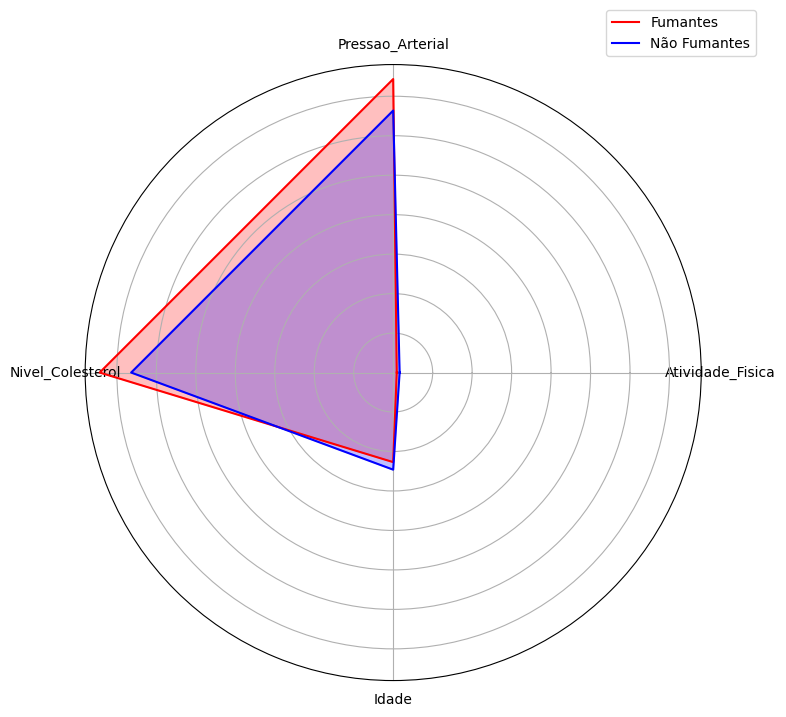

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Calculando a média para cada variável numérica
media_fumantes = df[df['Fumante'] == 'Sim'].mean(numeric_only=True)
media_nao_fumantes = df[df['Fumante'] == 'Não'].mean(numeric_only=True)

# Selecionando as variáveis numéricas
variaveis = ['Atividade_Fisica', 'Pressao_Arterial', 'Nivel_Colesterol', 'Idade']
valores_fumantes = [media_fumantes[var] for var in variaveis]
valores_nao_fumantes = [media_nao_fumantes[var] for var in variaveis]

# Número de variáveis
num_vars = len(variaveis)

# Calculando os ângulos dos eixos do gráfico de radar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Adicionando o valor inicial para fechar o gráfico
valores_fumantes += valores_fumantes[:1]
valores_nao_fumantes += valores_nao_fumantes[:1]

# Criando o gráfico de radar
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Mostrando os dados dos fumante
ax.fill(angles, valores_fumantes, color='red', alpha=0.25)
ax.plot(angles, valores_fumantes, color='red', label='Fumantes')

# Plotar os dados dos NÃO fumantes
ax.fill(angles, valores_nao_fumantes, color='blue', alpha=0.25)
ax.plot(angles, valores_nao_fumantes, color='blue', label='Não Fumantes')

# Colocando os rótulos aos eixos
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(variaveis)

# Colocando as legendas
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.show()

* Gráfico de radar com a normalização

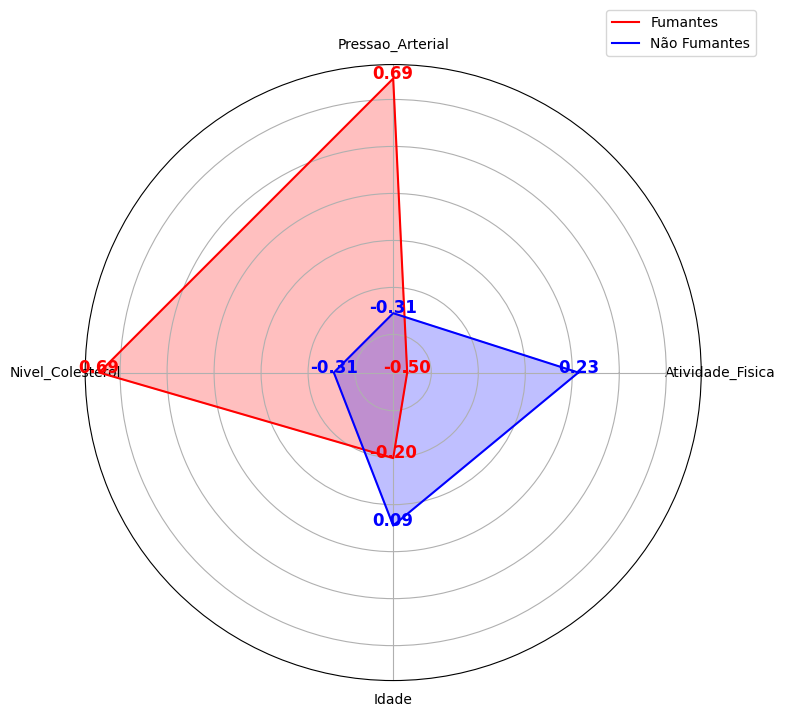

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from sklearn.preprocessing import StandardScaler

# Colunas com valores númericos
variaveis = ['Atividade_Fisica', 'Pressao_Arterial', 'Nivel_Colesterol', 'Idade']

# Normalizando as variáveis usando z-score
scaler = StandardScaler()
df_normalizado = df[variaveis].copy()
df_normalizado = scaler.fit_transform(df_normalizado)

# Calcular a média normalizada para fumantes e não fumantes
media_fumantes = df_normalizado[df['Fumante'] == 'Sim'].mean(axis=0)
media_nao_fumantes = df_normalizado[df['Fumante'] == 'Não'].mean(axis=0)

# Adicionando o valor inicial para fechar o gráfico
angles = np.linspace(0, 2 * np.pi, len(variaveis), endpoint=False).tolist()
angles += angles[:1]
valores_fumantes = list(media_fumantes) + [media_fumantes[0]]
valores_nao_fumantes = list(media_nao_fumantes) + [media_nao_fumantes[0]]

# Aqui eu tô criando o gráfico de radar
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Mostrando os dados dos fumante
ax.fill(angles, valores_fumantes, color='red', alpha=0.25)
ax.plot(angles, valores_fumantes, color='red', label='Fumantes')

# Mostrando os dados dos não fumantes
ax.fill(angles, valores_nao_fumantes, color='blue', alpha=0.25)
ax.plot(angles, valores_nao_fumantes, color='blue', label='Não Fumantes')

# Inserindo os rótulos aos eixos
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(variaveis)

# Adicionando os valores dos eixos
for i, var in enumerate(variaveis):
    angle = angles[i]
    ax.text(angle, valores_fumantes[i], f'{valores_fumantes[i]:.2f}', horizontalalignment='center', size=12, color='red', weight='semibold')
    ax.text(angle, valores_nao_fumantes[i], f'{valores_nao_fumantes[i]:.2f}', horizontalalignment='center', size=12, color='blue', weight='semibold')

# Adicionando a legenda
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.show()


## Atividade em sala 03

Crie um gráfico de radar que compare as variáveis numéricas para os indivíduos com e sem diabetes. O gráfico deve permitir a visualização clara das diferenças e semelhanças entre esses dois grupos em termos das variáveis analisadas.

Envie um relatório do gráfico num editor de texto ou no próprio collab.

## Agrupando dados

### Importação das Bibliotecas:

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

### Seleção das variáveis numéricas e normalização

In [ ]:
# Selecionando as variáveis numéricas
numeric_cols = ['Idade', 'IMC', 'Pressao_Arterial', 'Nivel_Colesterol', 'Atividade_Fisica']
df_numeric = df[numeric_cols]

# Normalizando os dados
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_numeric)

### Aplicando o algoritmo de agrupamento K-Means:

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)
df['Cluster'] = kmeans.labels_

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


### Gráfico de Dispersão 3D com Cores dos Clusters:

Objetivo: Visualizar a separação dos clusters em um espaço 3D, utilizando três variáveis numéricas importantes.

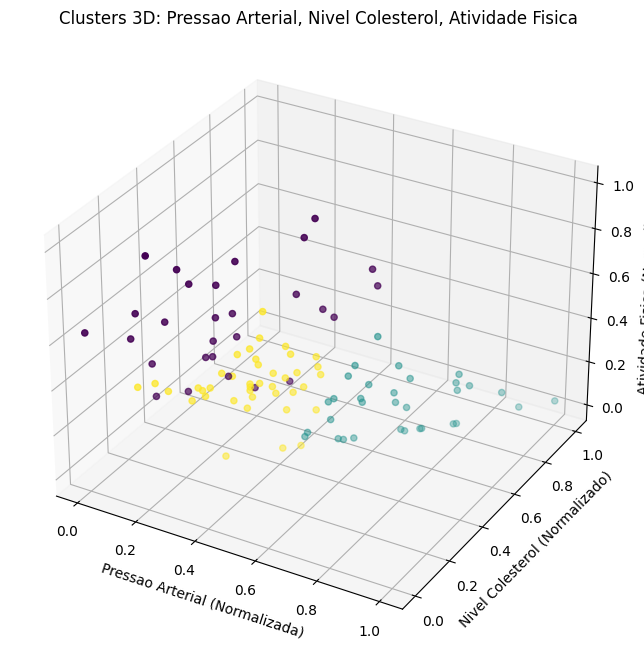

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
#Pressao_Arterial', 'Nivel_Colesterol', 'Atividade_Fisica'
ax.scatter(df_scaled[:, 2], df_scaled[:, 3], df_scaled[:, 4], c=df['Cluster'], cmap='viridis')
ax.set_xlabel('Pressao Arterial (Normalizada)')
ax.set_ylabel('Nivel Colesterol (Normalizado)')
ax.set_zlabel('Atividade Fisica (Normalizada)')
plt.title('Clusters 3D: Pressao Arterial, Nivel Colesterol, Atividade Fisica')
plt.show()

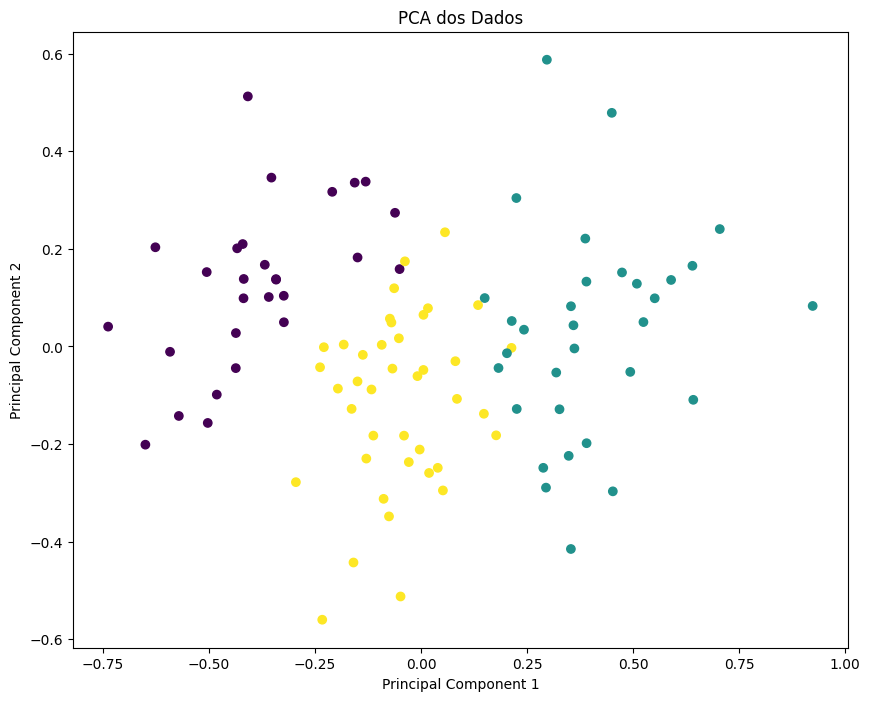

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aplicando PCA
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(df_scaled)

# Plotando os resultados
plt.figure(figsize=(10,8))
plt.scatter(principalComponents[:, 0], principalComponents[:, 1], c=df['Cluster'], cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA dos Dados')
plt.show()

### Heatmap de Correlação por Cluster:

Objetivo: Analisar as correlações entre as variáveis dentro de cada cluster.

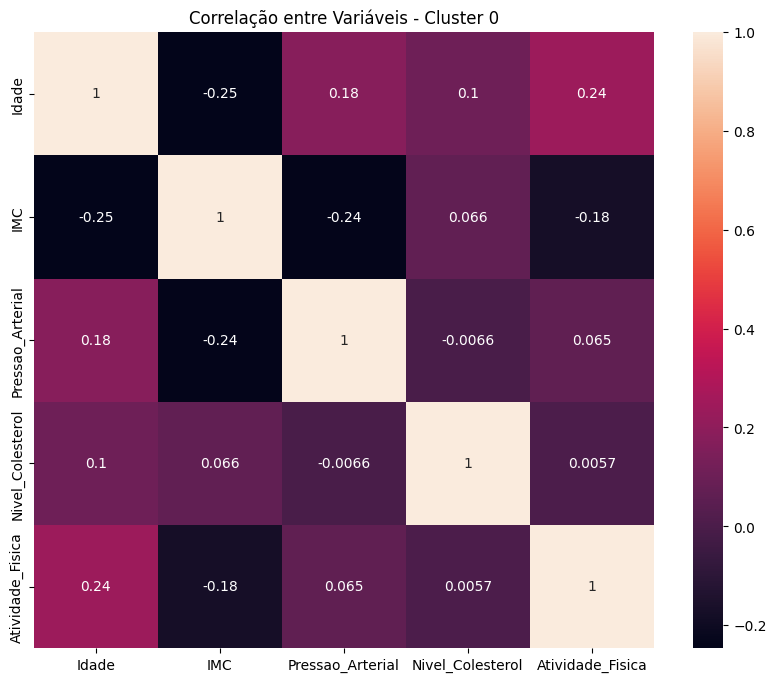

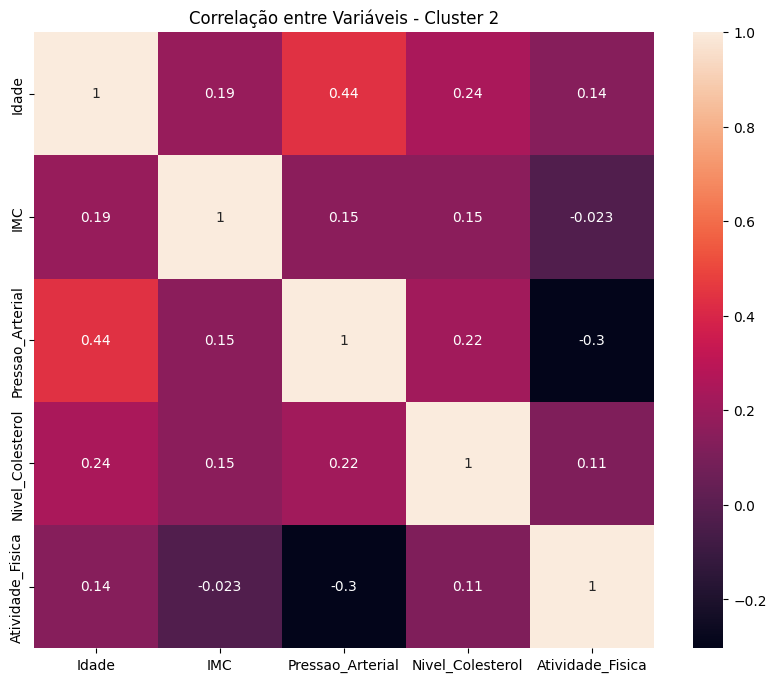

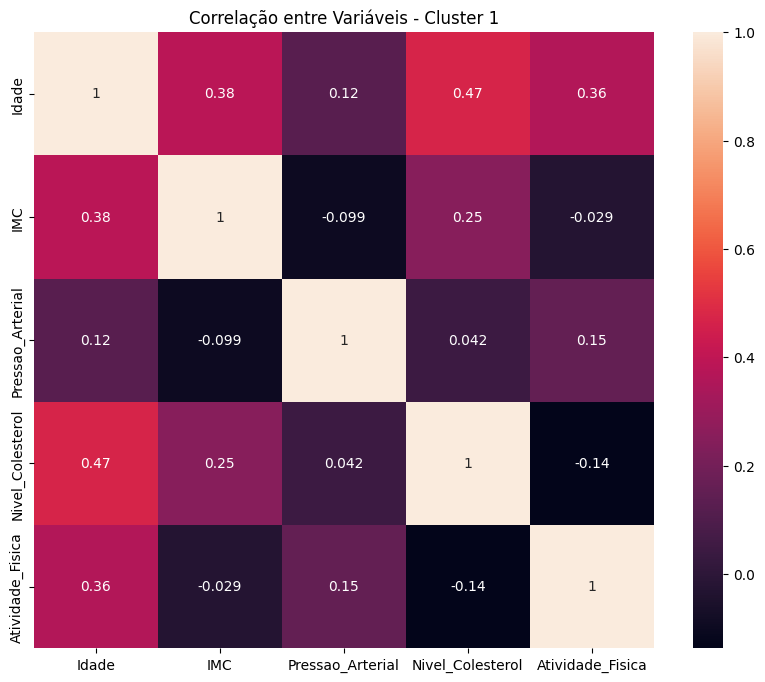

In [ ]:
import seaborn as sns

for cluster in df['Cluster'].unique():
    df_cluster = df[df['Cluster'] == cluster]
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_cluster[numeric_cols].corr(), annot=True)
    plt.title(f'Correlação entre Variáveis - Cluster {cluster}')
    plt.show()

### Gráfico de Barras Empilhadas:

Objetivo: Comparar a distribuição de variáveis categóricas entre os clusters.

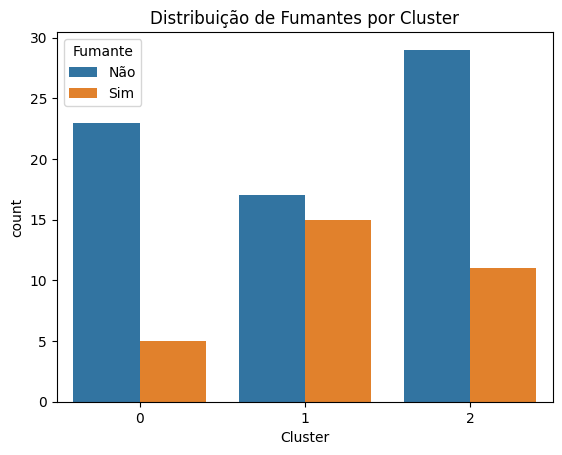

In [ ]:
# Exemplo: Comparando a distribuição de fumantes por cluster
sns.countplot(x='Cluster', hue='Fumante', data=df)
plt.title('Distribuição de Fumantes por Cluster')
plt.show()

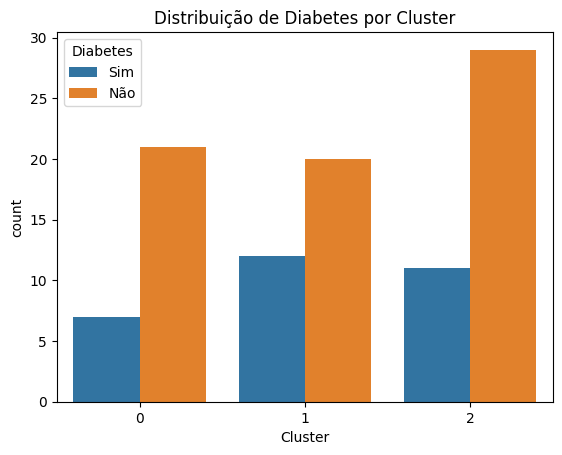

In [ ]:
# Exemplo: Comparando a distribuição de fumantes por cluster
sns.countplot(x='Cluster', hue='Diabetes', data=df)
plt.title('Distribuição de Diabetes por Cluster')
plt.show()

## Gráfico de radar de centróides de clusters

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


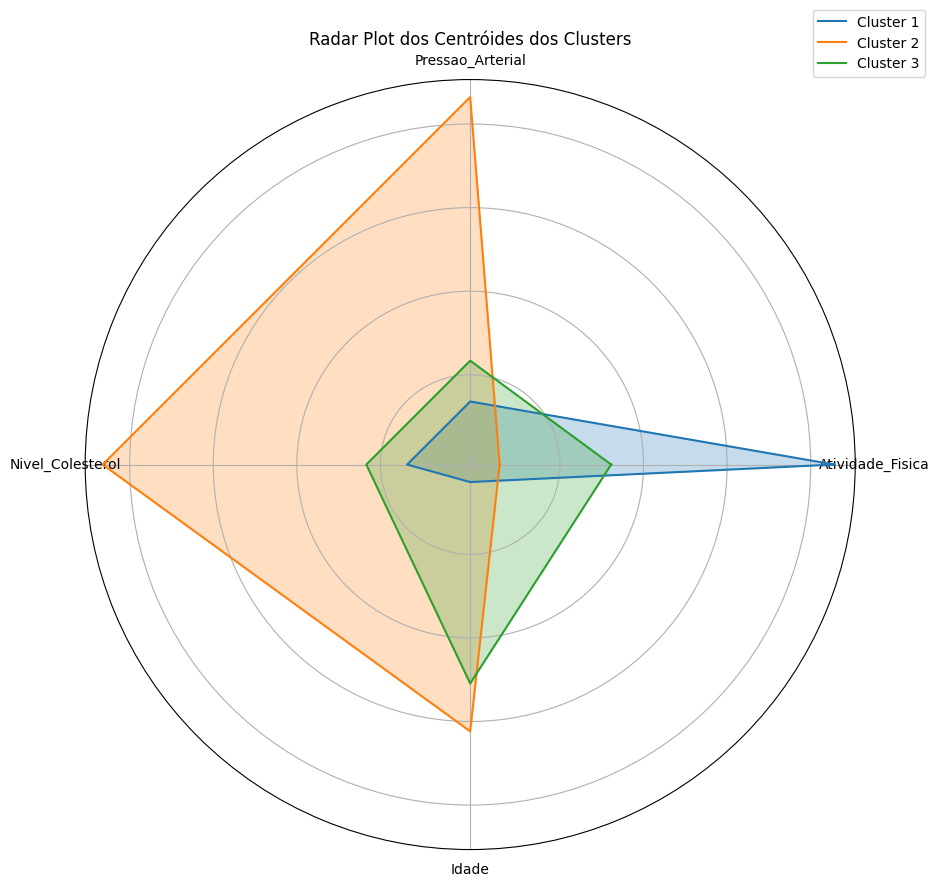

In [ ]:
from sklearn.preprocessing import StandardScaler
variaveis = ['Atividade_Fisica', 'Pressao_Arterial', 'Nivel_Colesterol', 'Idade']

# Normalizando os dados
scaler = StandardScaler()
df_normalizado = scaler.fit_transform(df[variaveis])

# Aplicando K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_normalizado)
df['Cluster'] = kmeans.labels_

# Obtendo os centróides
centroids = kmeans.cluster_centers_

# Criando os ângulos para o gráfico de radar
angles = np.linspace(0, 2 * np.pi, len(variaveis), endpoint=False).tolist()
angles += angles[:1]

# Função para criar um radar plot
def plot_radar(ax, angles, values, color, label):
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, values, color=color, label=label)

# Configurando o gráfico
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Criando um radar plot para cada centróide
for i, centroid in enumerate(centroids):
    values = list(centroid) + [centroid[0]]
    plot_radar(ax, angles, values, f'C{i}', f'Cluster {i+1}')

# Personalizando o gráfico
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(variaveis)
ax.set_title('Radar Plot dos Centróides dos Clusters')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.show()

## Atividade em Sala 04

### Elaboração de Relatório de Análise de Dados:

Com base nos gráficos gerados e discutidos durante a aula, elabore um relatório detalhado que resuma os principais padrões e insights encontrados. O relatório deve incluir:

* Descrição dos Gráficos: apresente alguns gráficos utilizados, incluindo seu propósito e as variáveis analisadas.
* Análise de Tendências e Padrões: identifique e discuta os padrões significativos, tendências e correlações observadas nos gráficos.
* Compare os diferentes grupos e variáveis para destacar qualquer diferença ou semelhança relevante.
Conclusões: baseado na análise, forneça conclusões e possíveis implicações dos padrões encontrados. Discuta como esses insights podem ser aplicados ou utilizados na prática.
Visualizações Incluídas: Inclua os gráficos no relatório para apoiar suas análises e conclusões.

O relatório pode ser redigido em um editor de texto como Writer ou Word e deve ser estruturado de forma clara e objetiva. Certifique-se de que a análise seja completa e que todos os gráficos apresentados sejam devidamente discutidos.

**O trabalho pode ser feito em grupo de até 3 alunos.**